In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers, callbacks

#1. Data
angles = np.random.uniform(-np.pi, np.pi, (1000,1))
sines  = np.sin(angles)

# 2. Model 
model = keras.Sequential([
    layers.Dense(50, activation='tanh', input_shape=(1,)),  # first hidden layer
    layers.Dense(50, activation='tanh'),                    # second hidden layer
    layers.Dense(1)                                         # linear output
])

In [2]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 50)             │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,701 (10.55 KB)

 Trainable params: 2,701 (10.55 KB)

 Non-trainable params: 0 (0.00 B)

In [3]:
#3. Compilation (with a lower learning rate for greater stability)
optimizer = keras.optimizers.Adam(learning_rate=0.01)
model.compile(optimizer=optimizer, loss='mean_squared_error')

#4. Early stopping callback to stop when there is no improvement.
early_stop = callbacks.EarlyStopping(
    monitor='loss',   
    patience=20,      
    restore_best_weights=True
)

In [5]:
# 5. Train
history = model.fit(
    angles, sines,
    epochs=500,
    batch_size=32,
    verbose=1,
    callbacks=[early_stop]
)


Epoch 1/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3774  
Epoch 2/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0269
Epoch 3/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0188
Epoch 4/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0173
Epoch 5/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0112
Epoch 6/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0113
Epoch 7/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0100
Epoch 8/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0087
Epoch 9/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0119
Epoch 10/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0076
Epoch 11/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0066
Epoch 12/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0096
Epoch 13/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0084
Epoch 14/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0075
Epoch 15/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0056
Ep

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


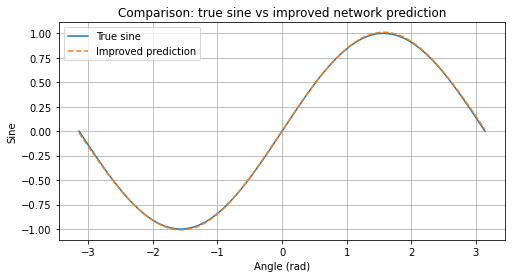

In [6]:
# 6.  Visual evaluation
x_vals = np.linspace(-np.pi, np.pi, 500).reshape(-1,1)
y_true = np.sin(x_vals)
y_pred = model.predict(x_vals)

plt.figure(figsize=(8,4))
plt.plot(x_vals, y_true, label='True sine')
plt.plot(x_vals, y_pred, '--', label='Improved prediction')
plt.legend()
plt.title("Comparison: true sine vs improved network prediction")
plt.xlabel("Angle (rad)")
plt.ylabel("Sine")
plt.grid(True)
plt.show()

# TFLITE Export

In [7]:
import tensorflow as tf
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS]
converter.inference_input_type = tf.float32
converter.inference_output_type = tf.float32
converted = converter.convert()

INFO:tensorflow:Assets written to: /tmp/tmp8ys31mps/assets


INFO:tensorflow:Assets written to: /tmp/tmp8ys31mps/assets


Saved artifact at '/tmp/tmp8ys31mps'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  125905449276992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125905449281920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125905449286672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125905449501264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125905449506368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125905449503376: TensorSpec(shape=(), dtype=tf.resource, name=None)


W0000 00:00:1772385797.892654   44983 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1772385797.892680   44983 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
2026-03-01 14:23:17.893196: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp8ys31mps
2026-03-01 14:23:17.893788: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-03-01 14:23:17.893798: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmp8ys31mps
I0000 00:00:1772385797.898283   44983 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled
2026-03-01 14:23:17.899067: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2026-03-01 14:23:17.923424: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmp8ys31mps
2026-03-01 14:23:17.935391: I tensorflow/cc/saved_model/loader.cc:471] SavedModel 

In [8]:
tflite_model_path = 'model_sine.tflite'
with open(tflite_model_path, 'wb') as f:
    f.write(converted)